<a id="summary"></a>

## Notebook 1 — Base EDA (`customers_raw`)

**v2.** This revision reflects updates to the upstream synthetic data: we fixed **state** distributions, ensured **`name`** and **`email`** are **unique** and **consistently paired** per customer (earlier builds could duplicate identities or misalign fields), and updated acquisition modeling to use **channel-specific CAC profiles** plus **channel-segment bias** (instead of segment-level CAC assumptions).

### How this notebook is organized

**Jump to parts:** [Part 1 — data quality & generator validation](#part-1) · [Part 2 — customer profile](#part-2)

**Part 1 — Main checks**

1. [Load `customers_raw` from Supabase](#q1)
2. [Data types (`df.info`)](#q2)
3. [Missing values](#q3)
4. [Row & column counts](#q4)
5. [Duplicate checks (`customer_id`, `email`, `name`)](#q5)
6. [`true_segment` counts vs planted design](#q6)
7. [`Acquisition channel` × `true_segment` (vs generator)](#q7)
8. [`Acquisition cost` vs generator assumptions](#q8)
9. [Monthly cohort (`registration_date`)](#q9)
10. [`Age` distribution](#q10)
11. [`State` distribution](#q11)

**Part 2 — Customer profile** 

12. [`Acquisition channel` × `state`](#q12)
13. [`Acquisition channel` × `age` band](#q13)
14. [`Acquisition channel` × `acquisition_cost` (CAC by channel)](#q14)
15. [`State` × `age` band ](#q15)
16. [Effective CAC per segment ](#q16)


---

### Objectives
- Run initial data quality checks for **data types**, **missing values**, and **duplicates**.
- Validate select columns against **`faker_base_generation`** assumptions.
- Understand customer distributions by **registration month**, **age**, **state**, **acquisition channel**, and planted **`true_segment`** (validation only).

### Scope
- This notebook works only on the **raw customer-level table** (`customers_raw`).
- No advanced feature engineering is performed here (no RFM, LTV, cohort *metrics beyond signup month counts*, or churn modeling).

### Expected output
A clean and trustworthy base view of the customer dataset that will support the next notebooks in the pipeline.


In [1]:
# ── Importing libraries ──────────────────────────────────────────────────────

import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

<a id="part-1"></a>

## Part 1 — Data quality & generator validation

**Goal:** confirm the `customers_raw` extract is structurally sound and that key fields match the **data-generation assumptions** (segment sizes, channel mix, acquisition cost).

[↑ Back to summary](#summary)


<a id="q1"></a>

### 1. Load `customers_raw` from Supabase

We connect to Supabase using SQLAlchemy and load the full `customers_raw` table. The preview with `head(5)` confirms the connection works and that all expected columns are present.

[↑ Back to summary](#summary)


In [2]:
# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql = text("""
SELECT
  customer_id,
  name,
  email,
  age,
  state,
  registration_date,
  acquisition_channel,
  acquisition_cost,
  true_segment
FROM public.customers_raw
ORDER BY registration_date DESC
""")

df_customers = pd.read_sql(sql, engine)
df_customers.head()

,customer_id,name,email,age,state,registration_date,acquisition_channel,acquisition_cost,true_segment
0,06761548-609b-4cf9-a61f-5ac2fc1e8036,Maya Abreu,maya.abreu@yahoo.com.br,41,RJ,2026-02-28 00:00:00+00:00,organic,13.17,low_value_dormant
1,0d019d34-81ad-4cd5-8c47-d5e812d8f02c,Dr. João Vitor das Neves,dr.neves7665@outlook.com,18,BA,2026-02-27 00:00:00+00:00,organic,13.32,low_value_dormant
2,e12b4555-965d-4b55-b681-e84c9387ecba,Miguel Caldeira,miguel.caldeira@outlook.com,18,SP,2026-02-26 00:00:00+00:00,referral,58.68,mid_value_regular
3,c6544c38-2606-4c88-8633-7986d1dd007d,Theodoro Azevedo,theodoro.azevedo@gmail.com,26,RS,2026-02-26 00:00:00+00:00,organic,10.66,at_risk_churner
4,48f363fd-ce49-418e-b148-db68bc35edee,Enrico da Paz,enrico.paz@yahoo.com.br,46,SP,2026-02-25 00:00:00+00:00,paid_ads,202.79,high_value_active


The table loaded successfully with all **9 columns** and **8,000 rows**. The preview confirms the expected schema — ready to proceed with quality checks.


<a id="q2"></a>

### 2. Data types

We call `df.info()` to inspect the inferred dtypes and verify that no column has an unexpected type or a suspicious null count before any further analysis.

[↑ Back to summary](#summary)


In [3]:
# Checking the data types
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   customer_id          8000 non-null   object             
 1   name                 8000 non-null   str                
 2   email                8000 non-null   str                
 3   age                  8000 non-null   int64              
 4   state                8000 non-null   str                
 5   registration_date    8000 non-null   datetime64[us, UTC]
 6   acquisition_channel  8000 non-null   str                
 7   acquisition_cost     8000 non-null   float64            
 8   true_segment         8000 non-null   str                
dtypes: datetime64[us, UTC](1), float64(1), int64(1), object(1), str(5)
memory usage: 562.6+ KB


Data types are correct. `registration_date` is a proper `datetime64[us, UTC]`, `age` and `acquisition_cost` are numeric, and all string fields use the `str` / `object` dtype. Potential conversions for `age` and `acquisition_cost` are noted for later modeling steps but are not blocking here.


<a id="q3"></a>

### 3. Missing values

We compute three complementary checks: **absolute count**, **percentage**, and the number of **rows with at least one null**. Because the dataset was intentionally generated without missing values, every count should be zero — any non-zero result would signal a bug in the generation pipeline or a loading error.

[↑ Back to summary](#summary)


In [4]:
# ── Missing-value quality check ──────────────────────────────────────────────
#
# Three standard methods, each catching different problems:
#
#  1. isnull().sum()       → absolute count of NaN per column (the usual first step)
#  2. isnull().mean() * 100 → percentage of NaN per column (better for large datasets)
#  3. isnull().any(axis=1) → flags entire rows that have at least one NaN anywhere
#
# Because this dataset was intentionally generated without missing values,
# every count should be 0. Any non-zero result would signal a bug in the
# generation pipeline or a data-loading issue.

missing_count = df_customers.isnull().sum()
missing_pct   = df_customers.isnull().mean() * 100
rows_with_any_null = df_customers.isnull().any(axis=1).sum()

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_%":     missing_pct.round(2),
})

print(f"Rows with at least one null: {rows_with_any_null} / {len(df_customers)}\n")
missing_summary

Rows with at least one null: 0 / 8000



,missing_count,missing_%
customer_id,0,0.0
name,0,0.0
email,0,0.0
age,0,0.0
state,0,0.0
registration_date,0,0.0
acquisition_channel,0,0.0
acquisition_cost,0,0.0
true_segment,0,0.0


No missing values in any column. All **8,000 rows** are fully populated — consistent with the synthetic data contract.


<a id="q4"></a>

### 4. Row & column counts

A quick `shape` check confirms the expected number of rows and columns before we proceed to more specific checks.

[↑ Back to summary](#summary)


In [5]:
# Checking the number of rows and columns
df_customers.shape

(8000, 9)

Shape is **8,000 × 9** — four planted segments (1,600 + 2,400 + 2,400 + 1,600) and the nine schema fields. No unexpected extra rows or columns.


<a id="q5"></a>

### 5. Duplicate checks

We check for **full-row duplicates** and key-level uniqueness across `customer_id`, `email`, and `name`. After the **v2** data-generation fix these three fields should all be unique.

[↑ Back to summary](#summary)


In [6]:
# ── Duplicated rows quality check ─────────────────────────────────────────
# This dataset is intended to have one row per customer_id.

full_dupe_mask = df_customers.duplicated(keep=False)
customer_id_dupe_mask = df_customers["customer_id"].duplicated(keep=False)
email_dupe_mask = df_customers["email"].duplicated(keep=False)
name_dupe_mask = df_customers["name"].duplicated(keep=False)

full_dupe_rows = int(full_dupe_mask.sum())
customer_id_dupe_rows = int(customer_id_dupe_mask.sum())
email_dupe_rows = int(email_dupe_mask.sum())
name_dupe_rows = int(name_dupe_mask.sum())

print(f"Duplicated full rows (all columns): {full_dupe_rows}")
print(f"Duplicated customer_id rows:      {customer_id_dupe_rows}")
print(f"Duplicated email rows:            {email_dupe_rows}")
print(f"Duplicated name rows:             {name_dupe_rows}")
if full_dupe_rows > 0:
    print("\nPreview of duplicated full rows:")
    display(df_customers.loc[full_dupe_mask].head(10))

if customer_id_dupe_rows > 0:
    print("\nPreview of duplicated customer_id rows:")
    display(df_customers.loc[customer_id_dupe_mask].sort_values("customer_id").head(10))

if email_dupe_rows > 0:
    print("\nPreview of duplicated email rows:")
    display(df_customers.loc[email_dupe_mask].sort_values("email").head(10))

if name_dupe_rows > 0:
    print("\nPreview of duplicated name rows:")
    display(df_customers.loc[name_dupe_mask].sort_values("name").head(10))


Duplicated full rows (all columns): 0
Duplicated customer_id rows:      0
Duplicated email rows:            0
Duplicated name rows:             0


No duplicates found. `customer_id`, `email`, and `name` are all unique — the v2 generator fix resolved the earlier identity-alignment issues.


<a id="q6"></a>

### 6. `true_segment` counts vs planted design

We count customers per `true_segment` and compare against the planted design (20% / 30% / 30% / 20%). This is a **generator sanity check** — `true_segment` is ground truth used only for model validation and is not surfaced on the commercial dashboard.

[↑ Back to summary](#summary)


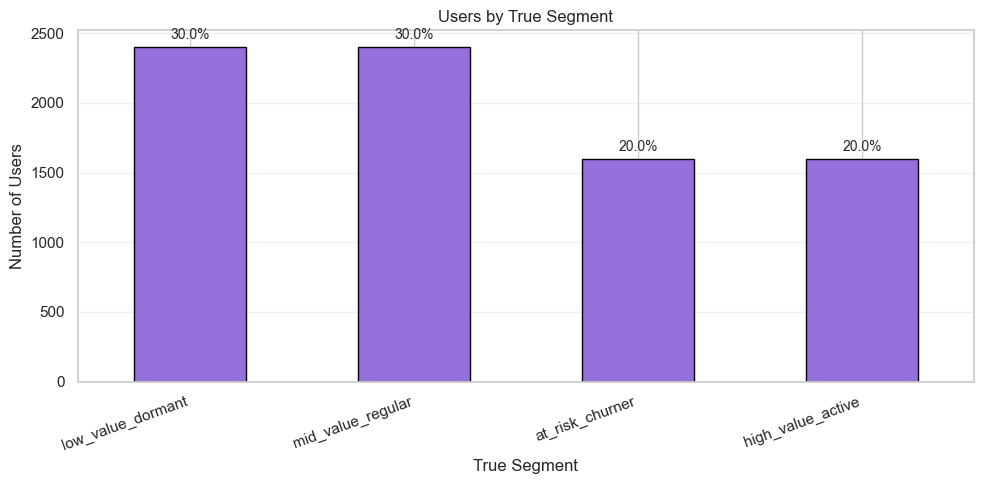

In [7]:
# True segment distribution
segment_counts = df_customers["true_segment"].value_counts().sort_values(ascending=False)
segment_pct = segment_counts / segment_counts.sum() * 100

ax = segment_counts.plot(kind="bar", figsize=(10, 5), color="mediumpurple", edgecolor="black")
plt.title("Users by True Segment")
plt.xlabel("True Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(segment_counts.values):
    ax.text(i, value + (segment_counts.max() * 0.015), f"{segment_pct.iloc[i]:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

Counts match the planted distribution exactly: **1,600** `high_value_active` (20%), **2,400** `mid_value_regular` (30%), **2,400** `low_value_dormant` (30%), and **1,600** `at_risk_churner` (20%). `true_segment` is intact and can be used as ground truth in cluster recovery and churn validation.


<a id="q7"></a>

### 7. `Acquisition channel` × `true_segment`

Based on the updated logic in `src/fintech_ai_segmentation/faker_base_generation.py`,
the generation now defines **channel-to-segment bias** first (`P(segment | channel)`), and then derives
`P(channel | segment)` for customer sampling.

Reference `P(segment | channel)` profiles:

- `organic`: **15%**, **35%**, **30%**, **20%**
- `referral`: **45%**, **35%**, **15%**, **5%**
- `partnership`: **20%**, **40%**, **25%**, **15%**
- `paid_ads`: **10%**, **20%**, **30%**, **40%**

Order above: `high_value_active`, `mid_value_regular`, `low_value_dormant`, `at_risk_churner`.

Derived segment-level channel probabilities (`paid_ads`, `organic`, `referral`, `partnership`):

- `high_value_active`: **11.11%**, **16.67%**, **50.00%**, **22.22%**
- `mid_value_regular`: **15.38%**, **26.92%**, **26.92%**, **30.77%**
- `low_value_dormant`: **30.00%**, **30.00%**, **15.00%**, **25.00%**
- `at_risk_churner`: **50.00%**, **25.00%**, **6.25%**, **18.75%**

This setup makes channel economics and segment composition emerge naturally from the data.

[↑ Back to summary](#summary)


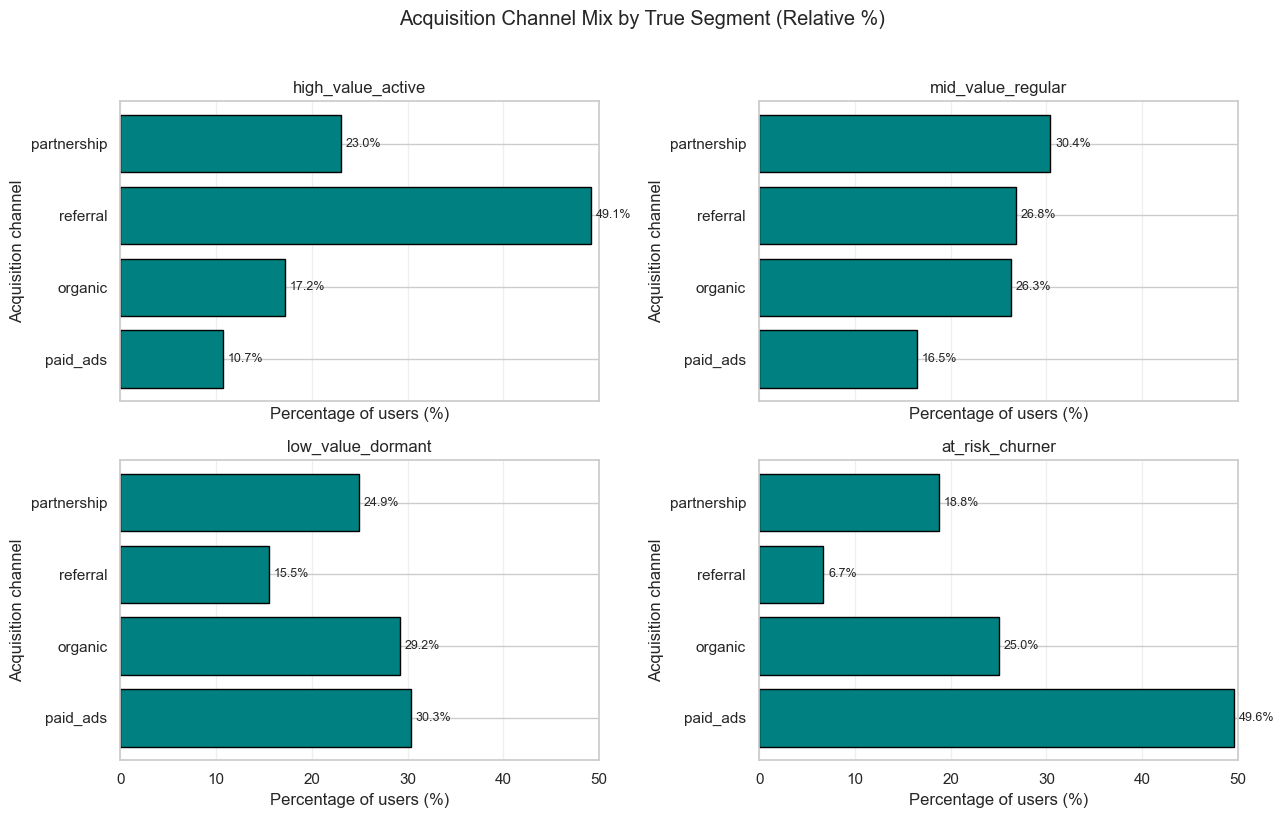

In [8]:
# Acquisition channel distribution by true_segment (relative %)
segment_order = [
    "high_value_active",
    "mid_value_regular",
    "low_value_dormant",
    "at_risk_churner",
]
channel_order = ["paid_ads", "organic", "referral", "partnership"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.flatten()

for ax, segment in zip(axes, segment_order):
    seg_df = df_customers[df_customers["true_segment"] == segment]
    rel_pct = (
        seg_df["acquisition_channel"]
        .value_counts(normalize=True)
        .reindex(channel_order, fill_value=0)
        .mul(100)
    )

    ax.barh(rel_pct.index, rel_pct.values, color="teal", edgecolor="black")
    ax.set_title(segment)
    ax.set_xlabel("Percentage of users (%)")
    ax.set_ylabel("Acquisition channel")
    ax.set_xlim(0, 50)
    ax.grid(axis="x", alpha=0.3)

    for y, value in enumerate(rel_pct.values):
        ax.text(value + 0.5, y, f"{value:.1f}%", va="center", fontsize=9)

plt.suptitle("Acquisition Channel Mix by True Segment (Relative %)", y=1.02)
plt.tight_layout()
plt.show()

The observed `acquisition_channel` distribution **matches the expected probabilities** from the data-generation process. This pattern is intentional from a business perspective: lower-cost channels (especially `organic` and `referral`) are designed to over-index in healthier segments, while higher-cost `paid_ads` is expected to bring a larger share of `at_risk_churner` customers. In other words, channel mix is not random noise; it encodes realistic go-to-market trade-offs between CAC efficiency and customer quality.

<a id="q8"></a>

### 8. Acquisition cost vs generator assumptions

The updated generator defines CAC assumptions by **acquisition channel** (not directly by `true_segment`).
So here we validate `acquisition_cost` against channel-level Normal profiles (`mean` / `std` / `floor`) to confirm that unit economics are embedded as intended.

[↑ Back to summary](#summary)


In [9]:
# Comparison with generator assumptions (mean/std by acquisition_channel)
assumptions = {
    "organic": {"expected_mean": 25, "expected_std": 10},
    "referral": {"expected_mean": 55, "expected_std": 15},
    "partnership": {"expected_mean": 110, "expected_std": 25},
    "paid_ads": {"expected_mean": 230, "expected_std": 50},
}

observed = (
    df_customers.groupby("acquisition_channel")["acquisition_cost"]
    .agg(observed_mean="mean", observed_std="std", observed_min="min", observed_max="max", n="count")
    .round(2)
)

comparison = observed.copy()
comparison["expected_mean"] = comparison.index.map(lambda s: assumptions[s]["expected_mean"])
comparison["expected_std"] = comparison.index.map(lambda s: assumptions[s]["expected_std"])
comparison["mean_diff"] = (comparison["observed_mean"] - comparison["expected_mean"]).round(2)
comparison["std_diff"] = (comparison["observed_std"] - comparison["expected_std"]).round(2)

# Reorder for readability from lower-CAC to higher-CAC channels.
comparison = comparison.reindex(["organic", "referral", "partnership", "paid_ads"])

display(comparison)
print("Note: values should be close to channel assumptions, with natural sampling variation.")

,observed_mean,observed_std,observed_min,observed_max,n,expected_mean,expected_std,mean_diff,std_diff
acquisition_channel,,,,,,,,,
organic,25.06,9.63,10.00,60.89,2007,25,10,0.06,-0.37
referral,54.71,15.09,10.00,111.66,1910,55,15,-0.29,0.09
partnership,109.46,24.98,30.30,221.98,1996,110,25,-0.54,-0.02
paid_ads,231.00,50.42,82.69,383.05,2087,230,50,1.00,0.42


Note: values should be close to channel assumptions, with natural sampling variation.


The observed means and standard deviations are close to the generator parameters for all four channels. The `observed_min` column confirms the R\$10 cost floor is **binding for `organic` and `referral`** (where near-zero draws get clipped, compressing the lower tail) but has **negligible effect on `partnership` and `paid_ads`** (means of R\$110 and R\$230 are far above the floor). The fit is consistent with expected sampling variation.

<a id="q8b"></a>

### 8b. Age vs generator assumptions

The generator assigns **segment-specific Normal distributions** to `age` via `_AGE_PARAMS_BY_SEGMENT`:

| Segment | Expected mean | Expected std |
|---|---|---|
| `high_value_active` | 38 | 9 |
| `mid_value_regular` | 33 | 10 |
| `low_value_dormant` | 42 | 12 |
| `at_risk_churner` | 27 | 8 |

We validate this planted signal the same way we validated CAC in item 8 — compare observed statistics against generator parameters, then visualise the distribution by segment.

[↑ Back to summary](#summary)

,expected_mean,observed_mean,mean_delta,expected_std,observed_std,std_delta,observed_min,observed_max
true_segment,,,,,,,,
high_value_active,38,37.39,-0.61,9,8.73,-0.27,18,64
mid_value_regular,33,32.81,-0.19,10,9.28,-0.72,18,66
low_value_dormant,42,41.62,-0.38,12,11.84,-0.16,18,80
at_risk_churner,27,27.02,0.02,8,7.07,-0.93,18,50


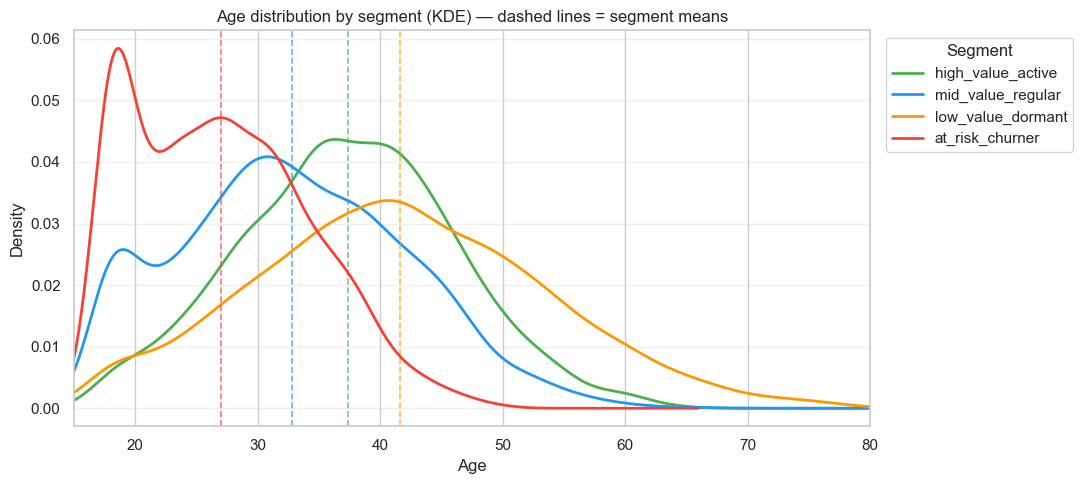

In [10]:
# ── Age vs generator assumptions ─────────────────────────────────────────────

# Generator parameters (from _AGE_PARAMS_BY_SEGMENT in faker_base_generation.py)
age_assumptions = {
    "high_value_active": {"expected_mean": 38, "expected_std": 9},
    "mid_value_regular":  {"expected_mean": 33, "expected_std": 10},
    "low_value_dormant":  {"expected_mean": 42, "expected_std": 12},
    "at_risk_churner":    {"expected_mean": 27, "expected_std": 8},
}

seg_order_age = ["high_value_active", "mid_value_regular", "low_value_dormant", "at_risk_churner"]

# Observed stats
age_observed = (
    df_customers.groupby("true_segment")["age"]
    .agg(observed_mean="mean", observed_std="std", observed_min="min", observed_max="max")
    .round(2)
    .reindex(seg_order_age)
)

age_comparison = age_observed.copy()
age_comparison["expected_mean"] = age_comparison.index.map(lambda s: age_assumptions[s]["expected_mean"])
age_comparison["expected_std"]  = age_comparison.index.map(lambda s: age_assumptions[s]["expected_std"])
age_comparison["mean_delta"]    = (age_comparison["observed_mean"] - age_comparison["expected_mean"]).round(2)
age_comparison["std_delta"]     = (age_comparison["observed_std"]  - age_comparison["expected_std"]).round(2)

display(age_comparison[[
    "expected_mean", "observed_mean", "mean_delta",
    "expected_std",  "observed_std",  "std_delta",
    "observed_min",  "observed_max"
]])

# ── KDE by segment ───────────────────────────────────────────────────────────

SEGMENT_COLORS = {
    "high_value_active": "#4CAF50",
    "mid_value_regular": "#2196F3",
    "low_value_dormant": "#FF9800",
    "at_risk_churner":   "#F44336",
}

fig, ax = plt.subplots(figsize=(11, 5))

for segment in seg_order_age:
    seg_ages = df_customers.loc[df_customers["true_segment"] == segment, "age"]
    color = SEGMENT_COLORS[segment]
    seg_ages.plot.kde(ax=ax, label=segment, color=color, linewidth=2)
    mean_val = seg_ages.mean()
    ax.axvline(mean_val, color=color, linestyle="--", linewidth=1.2, alpha=0.7)

ax.set_title("Age distribution by segment (KDE) — dashed lines = segment means")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend(title="Segment", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xlim(15, 80)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The observed means match generator parameters within < 1 year for every segment (expected given groups of 1,600–2,400 customers). The standard deviations are marginally tighter than expected — a natural effect of the `age = clip(normal, 18, 80)` bounds applied in the generator.

The KDE reveals the overlap structure:
- **`at_risk_churner`** (mean ≈ 27) and **`low_value_dormant`** (mean ≈ 42) are nearly non-overlapping — age alone cleanly separates these two.
- **`high_value_active`** (mean ≈ 38) and **`low_value_dormant`** (mean ≈ 42) share a substantial tail — **age has limited discriminatory power between them**. Any model using age as a feature should not expect it to cleanly separate these two segments.
- **`mid_value_regular`** (mean ≈ 33) overlaps with both `at_risk_churner` and `high_value_active`.

The business-facing consequence of this age correlation — how segment mix shifts across age bands — is shown in item 13b.

<a id="part-2"></a>

## Part 2 — Customer profile

**Goal:** build a picture of **who** customers are — registration patterns, demographics, and geography.

[↑ Back to summary](#summary)


<a id="q9"></a>

### 9. Monthly cohort (`registration_date`)

Customers are grouped by the **calendar month of their registration date** — the same cohort key used in **STEP 2 (cohort analysis)**. Here we only count how many customers joined each month; retention curves and cohort health metrics are computed in the next notebook.

[↑ Back to summary](#summary)


In [11]:
# ── Monthly cohort: customers per registration month ───────────────────────────

monthly_cohort = (
    df_customers.assign(
        cohort_month=df_customers["registration_date"].dt.to_period("M")
    )
    .groupby("cohort_month", sort=True)
    .size()
    .rename("customers")
)

monthly_cohort.to_frame()


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_12319/3167229781.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohort_month=df_customers["registration_date"].dt.to_period("M")


,customers
cohort_month,
2022-01,37
2022-02,75
2022-03,134
2022-04,160
2022-05,175
2022-06,207
2022-07,232
2022-08,257
2022-09,235


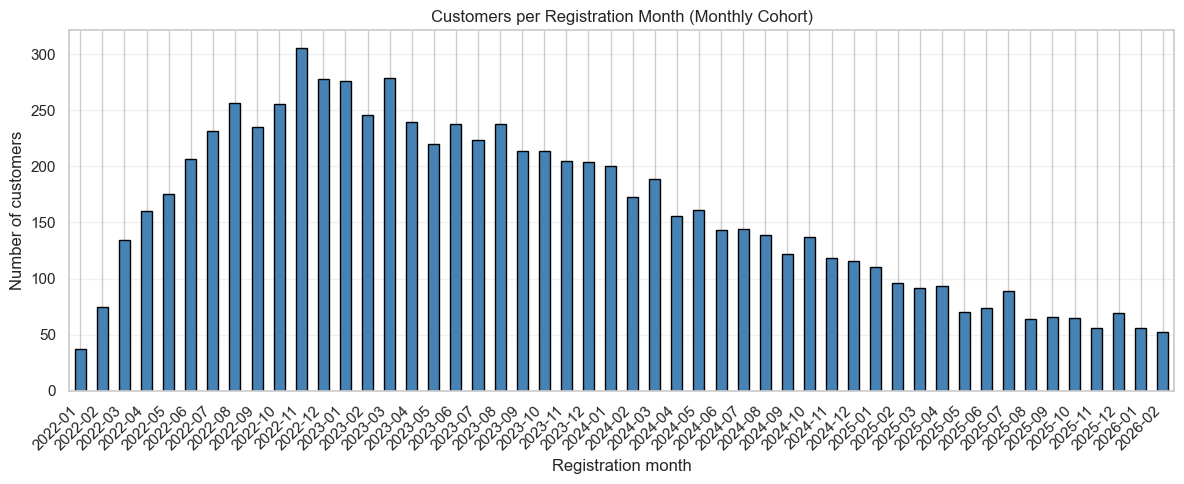

In [12]:
plt.figure(figsize=(12, 5))
monthly_cohort.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Customers per Registration Month (Monthly Cohort)")
plt.xlabel("Registration month")
plt.ylabel("Number of customers")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Registrations follow a **Gamma(2, 360)-shaped curve** — ramping up from ~35 customers in Jan 2022, peaking around **~305 in Nov 2022**, then declining gradually to ~50–70 in late 2025. This pattern reflects the startup acquisition life-cycle baked into the generator: rapid early growth followed by a long tail. **February 2026 is the last complete cohort** (the observation window ends on 2026‑03‑01, so no March 2026 bar exists). The tail months (roughly mid-2025 onward) have meaningfully smaller cohorts and should be treated with care in any month-over-month comparison.


**Analysis window note:** For behavioral metrics (RFM, spend trends, churn signals), the recommended window is **Mar 2024 – Feb 2026** — recent enough to reflect the current product, long enough to capture meaningful patterns.

For cohort-level comparisons (retention curves), the safe core is **Jan 2023 – Sep 2025**: early cohorts (pre-2023) may reflect a different acquisition process and product maturity, while cohorts registered after Sep 2025 have fewer than 6 months of observable behavior (cold-start zone).

**Note on segment breakdowns:** `registration_date` is drawn from the **same Gamma(2, 360) curve for all segments** — no cohort-segment signal is planted. Any apparent segment trend across cohort months reflects sampling noise in small early cells (35–100 customers), not a real shift in acquisition quality over time.

<a id="q10"></a>

### 10. Age distribution

We inspect the age distribution through summary statistics (mean, median, std, skewness, kurtosis) and a histogram. Age was generated from a clipped Normal distribution (mean ≈ 35, std = 10, range 18–80) — this check validates that the distribution behaves as designed and looks plausible.

[↑ Back to summary](#summary)


Descriptive statistics for customer age:
 count    8000.000000
mean       35.213000
std        11.023932
min        18.000000
25%        27.000000
50%        35.000000
75%        42.000000
max        80.000000
Name: age, dtype: float64


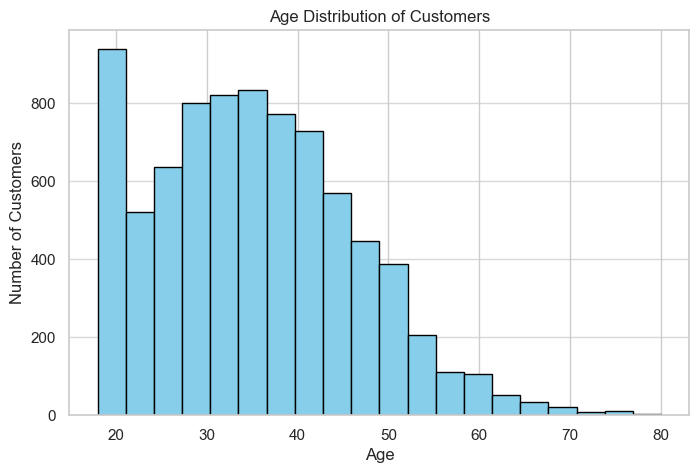

In [13]:
# Get descriptive statistics
age_desc = df_customers["age"].describe()
print("Descriptive statistics for customer age:\n", age_desc)

# Plot the histogram
plt.figure(figsize=(8, 5))
df_customers["age"].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(axis='y', alpha=0.75)
plt.show()


In [14]:
# Skewness and kurtosis for age distribution
age_skewness = df_customers["age"].skew()
age_kurtosis = df_customers["age"].kurt()

print(f"Age skewness: {age_skewness:.3f}")
print(f"Age kurtosis: {age_kurtosis:.3f}")

Age skewness: 0.484
Age kurtosis: 0.013


The global age distribution is realistic for a fintech customer base: ages range from 18 to 74, with mean ~34.5, median 34, and standard deviation = 11. Skewness of ~0.48 shows a mild right tail (slightly more older customers); kurtosis of ~-0.013 indicates a slightly flatter-than-normal shape without heavy tails.

**Important context:** `age` is not drawn from a single Normal distribution in this dataset — it is drawn from **segment-specific Normals** (mean 27–42 depending on segment). The global histogram looks approximately Normal because the mixture of four overlapping distributions smooths into a single hump. The segment-level breakdown and generator validation is in item **8b** above.

<a id="q11"></a>

### 11. State distribution

We count customers per Brazilian `state` to map geographic concentration. State probabilities were explicitly set in the generator (`STATE_PROBS` dict), so this chart also validates that the sampling matches the intended regional weights.

[↑ Back to summary](#summary)


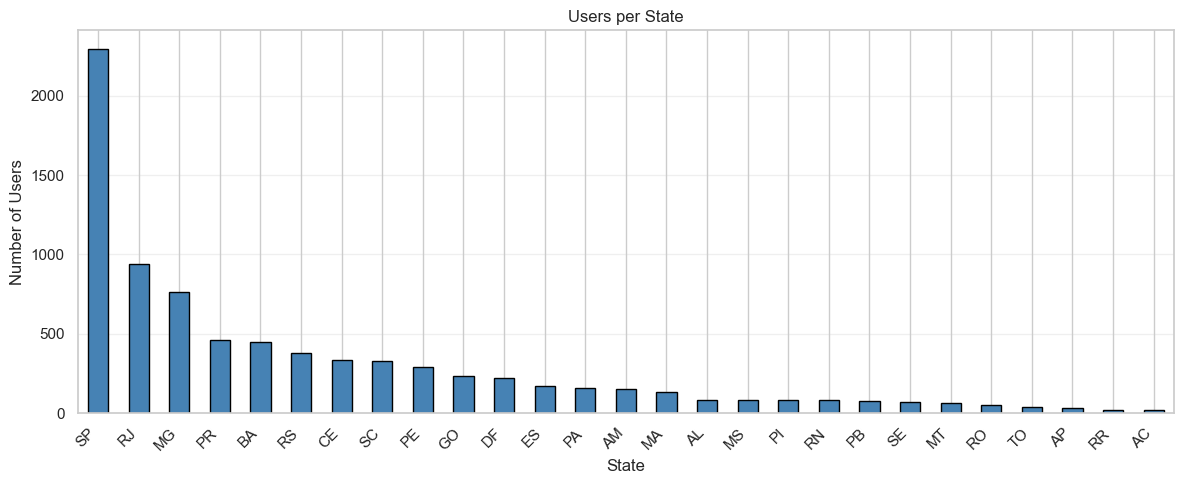

In [15]:
# Users per state
state_counts = df_customers["state"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
state_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Users per State")
plt.xlabel("State")
plt.ylabel("Number of Users")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Users per state — Customer counts are very uneven: SP dominates (~2.3k), with RJ and MG next; several states form a mid tail, and AC, AP, RR (and similar) are barely visible. That pattern matches heavy Southeast weighting and a long tail of small-N states, so any story or model by state should treat SP/RJ/MG as high-signal cells and rare states as low sample size.

<a id="q12"></a>

### 12. Acquisition channel × state (top states — 70% of users)

We want to understand whether different **acquisition channels** are more or less prevalent in specific regions. Because most Brazilian states have very few customers, we **restrict the view to the top states that together account for ≥ 70% of the user base** (cumulative share), keeping the chart readable and statistically meaningful.

[↑ Back to summary](#summary)


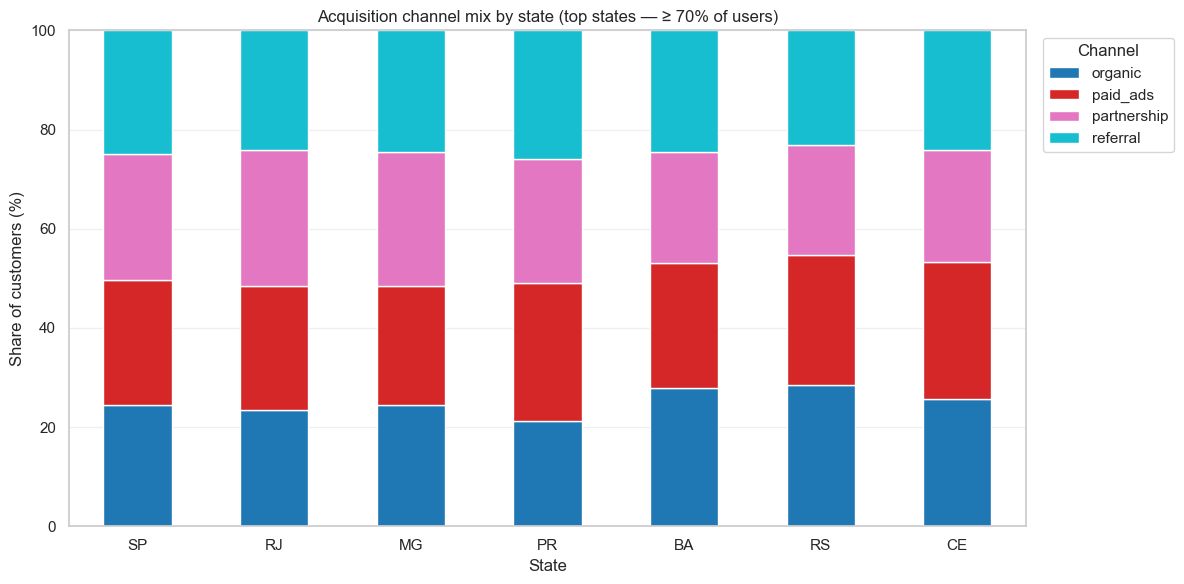


Top states (≥ 70% cumulative): ['SP', 'RJ', 'MG', 'PR', 'BA', 'RS', 'CE']
Cumulative share: 70.3%


In [16]:
# ── Acquisition channel × state (top states covering ≥ 70% of users) ────────

# Identify top states that together reach ≥ 70% cumulative share
state_counts = df_customers["state"].value_counts()
state_share  = state_counts / state_counts.sum()
cumulative   = state_share.cumsum()
top_states   = cumulative[cumulative <= 0.70].index.tolist()
# Include the next state that crosses the 70% threshold
if len(top_states) < len(cumulative):
    top_states.append(cumulative.index[len(top_states)])

df_top = df_customers[df_customers["state"].isin(top_states)].copy()

# Relative % of each channel within each top state
channel_by_state = (
    df_top.groupby(["state", "acquisition_channel"])
    .size()
    .unstack(fill_value=0)
)
channel_by_state_pct = channel_by_state.div(channel_by_state.sum(axis=1), axis=0) * 100
# Sort states by total users (largest first)
channel_by_state_pct = channel_by_state_pct.loc[
    state_counts[top_states].sort_values(ascending=False).index
]

# Stacked bar chart
ax = channel_by_state_pct.plot(
    kind="bar", stacked=True,
    figsize=(12, 6),
    colormap="tab10",
    edgecolor="white",
)
ax.set_title("Acquisition channel mix by state (top states — ≥ 70% of users)")
ax.set_xlabel("State")
ax.set_ylabel("Share of customers (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Channel", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop states (≥ 70% cumulative): {top_states}")
print(f"Cumulative share: {state_share[top_states].sum():.1%}")


The stacked bars show that **channel mix is broadly similar across top states** — no single state appears to be dominated exclusively by one channel. This is expected because the generator assigns channels using a synthetic **segment-channel bias model** (channel economics + segment propensity), not a geography-specific rule. So geographic variation mostly reflects the **segment composition of each state** rather than a deliberate regional strategy. Any channel divergence between states is therefore a signal of **segment skew** in that state, not a separate marketing decision. In a real dataset, meaningful differences here would motivate **state-level channel attribution** and budget re-allocation.


<a id="q13"></a>

### 13. Acquisition channel × age (lifecycle bands)

We group `age` into **standard lifecycle bands** used in retail and digital banking reporting:

- **18–24** — young adults (early career, high digital adoption)
- **25–34** — core millennial segment (typical primary fintech target)
- **35–44** — established professionals and family formation
- **45–54** — mid-career / peak earning years
- **55+** — pre-retirement and older customers

For each band we show the **share of customers by acquisition channel** (each stacked bar sums to 100%), so we can compare channel mix across life stages without being skewed by how many people fall in each band.

[↑ Back to summary](#summary)


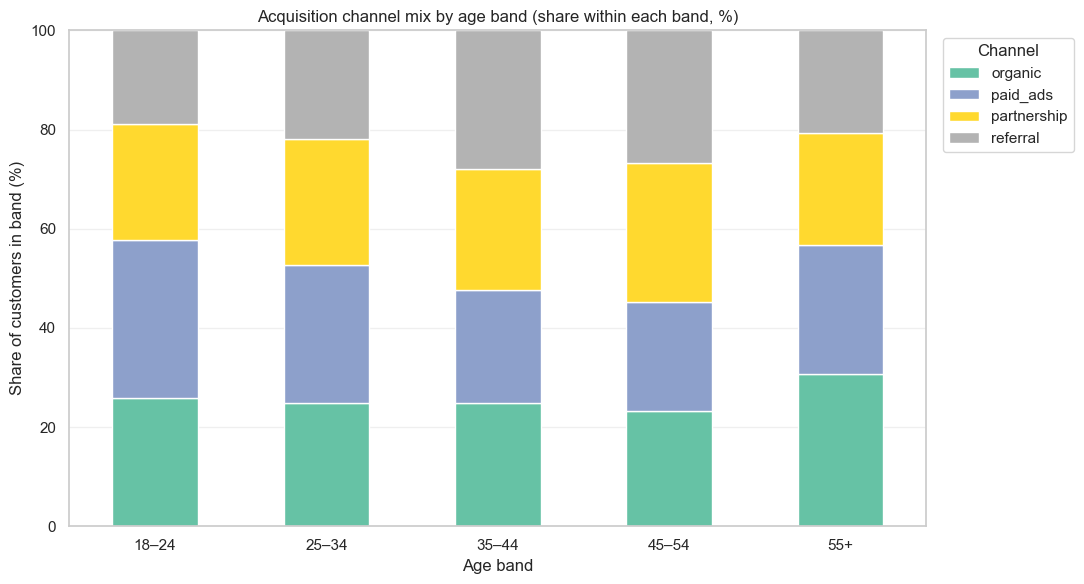

acquisition_channel  organic  paid_ads  partnership  referral
age_band                                                     
18–24                    377       466          342       275
25–34                    627       705          643       557
35–44                    611       559          597       686
45–54                    267       252          322       308
55+                      125       105           92        84


In [17]:
# ── Acquisition channel × age band (lifecycle) ─────────────────────────────

# Business-oriented bands: align with common CRM / campaign segmentation
df_age = df_customers.copy()
df_age["age_band"] = pd.cut(
    df_age["age"],
    bins=[17, 24, 34, 44, 54, 120],
    labels=["18–24", "25–34", "35–44", "45–54", "55+"],
    right=True,
)

# Relative % of each channel within each age band (readable mix comparison)
ch_by_band = (
    df_age.groupby(["age_band", "acquisition_channel"], observed=True)
    .size()
    .unstack(fill_value=0)
)
ch_by_band_pct = ch_by_band.div(ch_by_band.sum(axis=1), axis=0) * 100

ax = ch_by_band_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="Set2",
    edgecolor="white",
)
ax.set_title("Acquisition channel mix by age band (share within each band, %)")
ax.set_xlabel("Age band")
ax.set_ylabel("Share of customers in band (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Channel", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(ch_by_band.astype(int).rename_axis(index="age_band").to_string())


Channel mix is **similar across age bands**, and the reason is structural: in this generator, `acquisition_channel` is sampled from **segment-specific probabilities**, not from age. Age bands show similar channel mixes because **segment composition shifts gradually across bands** — not because there is a direct age-channel rule. The channel mix in the 18–24 band looks similar to the 35–44 band because each band contains a similar *weighted blend* of segments (the weights shift, but not enough to produce a clearly different channel mix).

For the view that *does* shift clearly with age — the **segment mix within each band** — see item **13b** below.

<a id="q13b"></a>

### 13b. Segment mix within age band

The previous item confirmed that `acquisition_channel` does not vary by age band. Here we examine **what does** vary: the **share of each `true_segment` within each age band**. Since the generator draws `age` from segment-specific Normal distributions, each band naturally tilts toward different segments.

[↑ Back to summary](#summary)

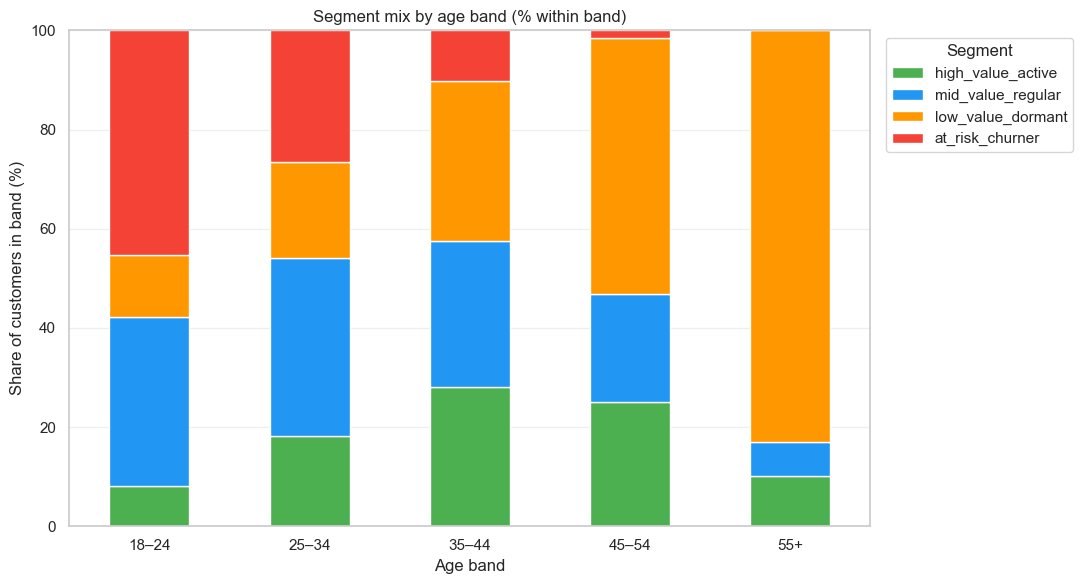

Customer counts — segment × age band:

true_segment  high_value_active  mid_value_regular  low_value_dormant  at_risk_churner
age_band                                                                              
18–24                       119                497                182              662
25–34                       461                907                491              673
35–44                       690                719                796              248
45–54                       289                249                594               17
55+                          41                 28                337                0

Percentage breakdown:

true_segment  high_value_active  mid_value_regular  low_value_dormant  at_risk_churner
age_band                                                                              
18–24                       8.2               34.0               12.5             45.3
25–34                      18.2               35.8               19

In [18]:
# ── Segment mix within age band ──────────────────────────────────────────────

# Reuse df_age (defined in item 13 above)
seg_order = ["high_value_active", "mid_value_regular", "low_value_dormant", "at_risk_churner"]
band_order = ["18–24", "25–34", "35–44", "45–54", "55+"]

SEGMENT_COLORS = {
    "high_value_active": "#4CAF50",
    "mid_value_regular": "#2196F3",
    "low_value_dormant": "#FF9800",
    "at_risk_churner":   "#F44336",
}

seg_by_band = (
    df_age.groupby(["age_band", "true_segment"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=band_order, columns=seg_order, fill_value=0)
)

seg_by_band_pct = seg_by_band.div(seg_by_band.sum(axis=1), axis=0) * 100

colors = [SEGMENT_COLORS[s] for s in seg_order]
ax = seg_by_band_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=colors,
    edgecolor="white",
)
ax.set_title("Segment mix by age band (% within band)")
ax.set_xlabel("Age band")
ax.set_ylabel("Share of customers in band (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Segment", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Customer counts — segment × age band:\n")
print(seg_by_band.astype(int).to_string())
print("\nPercentage breakdown:\n")
print(seg_by_band_pct.round(1).to_string())

The stacked bars show the business-facing payoff of the age-segment correlation planted in the generator:

- **18–24:** skews heavily toward **`at_risk_churner`** (~45%) — the youngest band is the highest-churn segment. Campaigns targeting under-25 customers face the highest disengagement risk.
- **25–34:** `at_risk_churner` still elevated above the global average; `mid_value_regular` starts to dominate.
- **35–44:** the most balanced band — closest to the global 20/30/30/20 split. `high_value_active` peaks here.
- **45–54:** `low_value_dormant` begins to dominate.
- **55+:** overwhelmingly **`low_value_dormant`** (~80%+) — older customers are designed to transact rarely and disengage early.

These are **not causal** claims. Age is a **proxy signal**, not a driver — the underlying driver is `true_segment`, which was generated independently of age and then correlated via the sampling design. In production, age would be used as a feature alongside RFM and cohort metrics, not as a standalone predictor.

<a id="q14"></a>

### 14. Acquisition channel × acquisition cost (CAC efficiency preview)

Here we compare **customer acquisition cost (CAC)** — stored as `acquisition_cost` — **by acquisition channel**. The goal is **channel efficiency**: typical cost (center) and **spread** (variability) per channel, before any lifetime value adjustment. This is a **preview** of the unit-economics lens; **STEP 4** will combine CAC with **LTV** for full payback and ratio analysis.

[↑ Back to summary](#summary)


Summary statistics — acquisition_cost (R$) by channel:

                     count    mean  median    std     p25     p75
acquisition_channel                                              
organic               2007   25.06   24.66   9.63   17.50   31.94
paid_ads              2087  231.00  232.53  50.42  197.03  265.82
partnership           1996  109.46  109.09  24.98   92.30  126.20
referral              1910   54.71   54.54  15.09   44.42   64.09


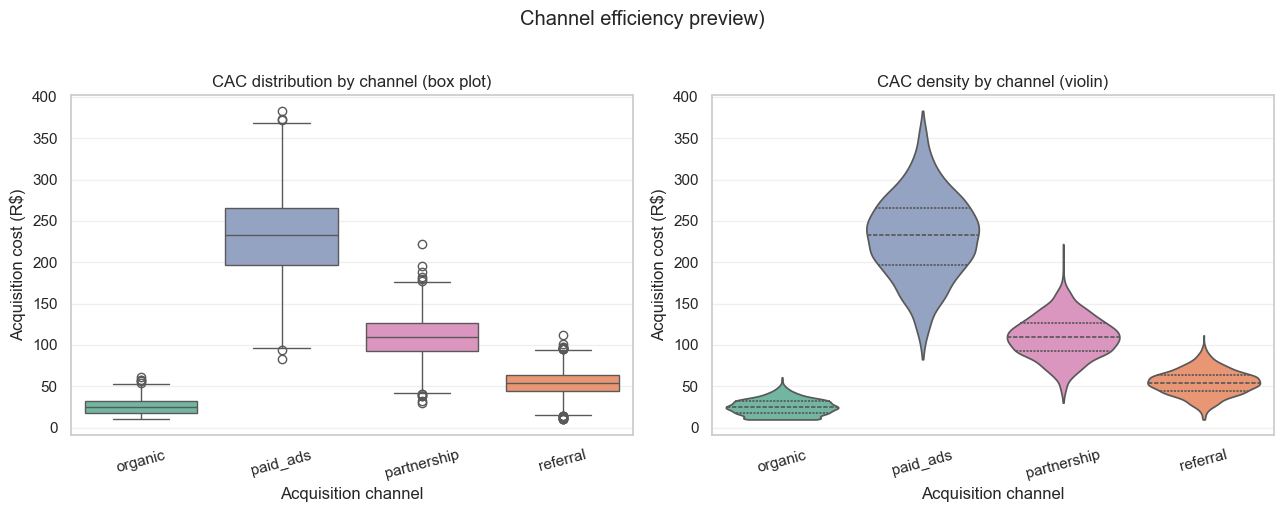

In [24]:
# ── CAC by acquisition channel (typical level & spread) ───────────────────

cac_summary = (
    df_customers.groupby("acquisition_channel")["acquisition_cost"]
    .agg(count="count", mean="mean", median="median", std="std", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
    .round(2)
)
print("Summary statistics — acquisition_cost (R$) by channel:\n")
print(cac_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

channel_order = sorted(df_customers["acquisition_channel"].unique())
sns.boxplot(
    data=df_customers,
    x="acquisition_channel",
    y="acquisition_cost",
    order=channel_order,
    ax=axes[0],
    hue="acquisition_channel",
    palette="Set2",
    legend=False,
    dodge=False,
)
axes[0].set_title("CAC distribution by channel (box plot)")
axes[0].set_xlabel("Acquisition channel")
axes[0].set_ylabel("Acquisition cost (R$)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

sns.violinplot(
    data=df_customers,
    x="acquisition_channel",
    y="acquisition_cost",
    order=channel_order,
    ax=axes[1],
    hue="acquisition_channel",
    palette="Set2",
    legend=False,
    inner="quartile",
    cut=0,
    dodge=False,
)
axes[1].set_title("CAC density by channel (violin)")
axes[1].set_xlabel("Acquisition channel")
axes[1].set_ylabel("Acquisition cost (R$)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Channel efficiency preview)", y=1.02)
plt.tight_layout()
plt.show()


**Takeaway:** Each channel shows a distinct **central tendency** and **dispersion** in `acquisition_cost`. In this synthetic setup, that separation is intentional: CAC is sampled from **channel-specific Normal profiles** (`organic` < `referral` < `partnership` < `paid_ads`) with a floor at `R$10`, while segment-channel bias shapes who arrives through each channel. For commercial decisions, treat this view as **where CAC concentrates** by channel;

<a id="q15"></a>

### 15. State × age band — generator sanity check (expected: no pattern)

This is a **null-result validation**, not a business insight. In the generator, `state` is drawn from `STATE_PROBS` independently of `age` and `true_segment`. We expect no systematic relationship between state and age band.

We use the **same top states** (≥70% cumulative) and **same age bands** as items 12 and 13. The heatmap shows the percentage of customers in each age band per state (rows sum to 100%). We then confirm the null result with a chi-square test of independence.

[↑ Back to summary](#summary)

Customer counts — state × age band (top states only):

age_band  18–24  25–34  35–44  45–54  55+
state                                    
SP          409    722    728    321  118
RJ          165    298    275    147   57
MG          141    237    227    118   41
PR           93    149    127     68   22
BA           76    140    145     67   18
RS           68    118    126     47   19
CE           58     98    107     48   25

Top states (≥ 70% cumulative): ['SP', 'RJ', 'MG', 'PR', 'BA', 'RS', 'CE']
Cumulative share of base: 70.3%


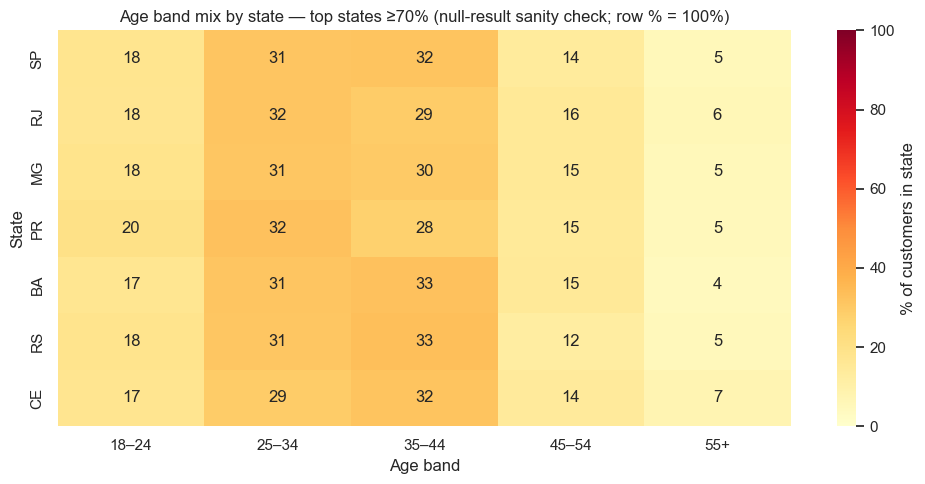


Chi-square test of independence (state × age band):
  chi2 = 15.63,  p-value = 0.9009,  df = 24
  Cramér's V = 0.0264  (effect size; 0 = no association)
  p > 0.05 — confirms no significant association between state and age band.


In [20]:
# ── State × age band (top states ≥70% + same bands as item 13) ────────────
from scipy import stats
import numpy as np

# Top states — identical logic to item 12
state_counts = df_customers["state"].value_counts()
state_share = state_counts / state_counts.sum()
cumulative = state_share.cumsum()
top_states = cumulative[cumulative <= 0.70].index.tolist()
if len(top_states) < len(cumulative):
    top_states.append(cumulative.index[len(top_states)])

df_sa = df_customers[df_customers["state"].isin(top_states)].copy()

# Age bands — identical bins/labels to item 13
df_sa["age_band"] = pd.cut(
    df_sa["age"],
    bins=[17, 24, 34, 44, 54, 120],
    labels=["18–24", "25–34", "35–44", "45–54", "55+"],
    right=True,
)

band_order = ["18–24", "25–34", "35–44", "45–54", "55+"]

# Counts and row-% (mix within state)
ct_counts = pd.crosstab(df_sa["state"], df_sa["age_band"])
state_row_order = state_counts[top_states].sort_values(ascending=False).index
ct_counts = ct_counts.reindex(index=state_row_order)
ct_counts = ct_counts.reindex(columns=[b for b in band_order if b in ct_counts.columns])

ct_pct = ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100

print("Customer counts — state × age band (top states only):\n")
print(ct_counts.astype(int).to_string())
print(f"\nTop states (≥ 70% cumulative): {list(top_states)}")
print(f"Cumulative share of base: {state_share[top_states].sum():.1%}")

fig_h = max(5.0, len(ct_pct) * 0.45)
fig, ax = plt.subplots(figsize=(10, fig_h))
sns.heatmap(
    ct_pct,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% of customers in state"},
)
ax.set_title(
    "Age band mix by state — top states ≥70% (null-result sanity check; row % = 100%)"
)
ax.set_xlabel("Age band")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

# ── Chi-square test of independence ──────────────────────────────────────────
chi2, p_val, dof, _ = stats.chi2_contingency(ct_counts)
n = ct_counts.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_counts.shape) - 1)))

print(f"\nChi-square test of independence (state × age band):")
print(f"  chi2 = {chi2:.2f},  p-value = {p_val:.4f},  df = {dof}")
print(f"  Cramér's V = {cramers_v:.4f}  (effect size; 0 = no association)")
if p_val < 0.05:
    print(f"  p < 0.05 — statistically significant, but Cramér's V ≈ 0 means the effect size is negligible.")
    print(f"  With {n:,} customers across {ct_counts.shape[0]} states × {ct_counts.shape[1]} bands, the test has high power")
    print(f"  and will flag sampling noise as 'significant'. Cramér's V is the relevant metric here.")
else:
    print(f"  p > 0.05 — confirms no significant association between state and age band.")

The heatmap rows look similar across states — consistent with the generator's independent sampling of `age` and `state`. The chi-square test provides statistical backing: **Cramér's V near 0 confirms no meaningful association** between state and age band, regardless of whether the p-value crosses 0.05 (with ~5,600 customers in 35 cells, the test has high power to flag sampling noise as significant).

This analysis is a **sanity check on the generator design**, not a source of business insight. In a production dataset with real acquisition patterns, material row differences here would support state-specific lifecycle targeting (e.g. younger-skewed regions may warrant different retention campaigns).

<a id="q16"></a>

### 16. Effective CAC per segment

The earlier analyses showed **CAC by channel** and **channel bias by segment** separately. Here we connect them: each segment has a different channel mix, so its **blended acquisition cost** differs even if no channel's price changes.

We compute **per-segment CAC statistics** (mean, median, std, p25/p75) directly from `acquisition_cost` grouped by `true_segment`. This gives the **effective (weighted) cost** of acquiring one customer in each segment — the denominator needed for a CAC/LTV ratio.

[↑ Back to summary](#summary)


Effective CAC by segment:

                      n    mean  median    std    p25     p75
true_segment                                                 
high_value_active  1600   80.68   59.14  63.52  40.14  102.78
mid_value_regular  2400   92.47   69.81  73.61  35.63  122.20
low_value_dormant  2400  112.50   90.66  88.60  33.33  186.14
at_risk_churner    1600  146.47  141.15  98.48  41.33  235.90


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_12319/2252246681.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


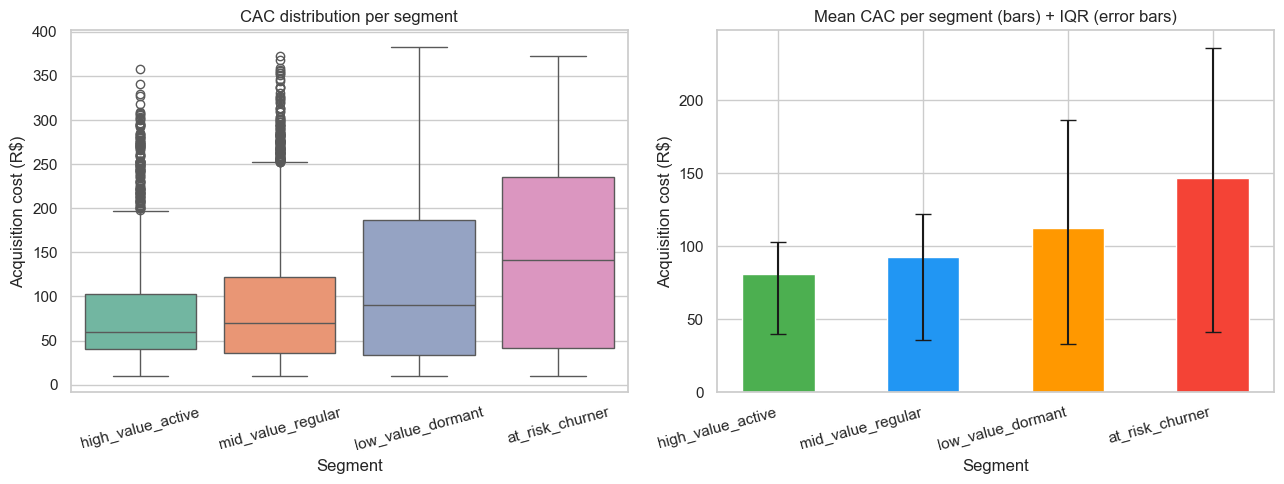

In [21]:
# ── Effective (blended) CAC per segment ────────────────────────────────────

seg_order = ["high_value_active", "mid_value_regular", "low_value_dormant", "at_risk_churner"]

cac_seg = (
    df_customers.groupby("true_segment")["acquisition_cost"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .round(2)
    .reindex(seg_order)
)

print("Effective CAC by segment:\n")
print(cac_seg.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: boxplot
sns.boxplot(
    data=df_customers,
    x="true_segment",
    y="acquisition_cost",
    order=seg_order,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("CAC distribution per segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Acquisition cost (R$)")
axes[0].tick_params(axis="x", rotation=15)

# Right: mean + IQR bar chart
x = range(len(seg_order))
axes[1].bar(
    x,
    cac_seg["mean"],
    yerr=[cac_seg["mean"] - cac_seg["p25"], cac_seg["p75"] - cac_seg["mean"]],
    color=["#4CAF50", "#2196F3", "#FF9800", "#F44336"],
    capsize=6,
    width=0.5,
)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(seg_order, rotation=15, ha="right")
axes[1].set_title("Mean CAC per segment (bars) + IQR (error bars)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Acquisition cost (R$)")

plt.tight_layout()
plt.show()


**`at_risk_churner`** carries the **highest effective CAC** — driven by its over-index on `paid_ads` (typical ~R$230). **`high_value_active`** has the **lowest blended cost** because it over-indexes on `referral` and `organic`. This creates a compounding disadvantage: the segment most likely to churn is also the most expensive to acquire.


<a id="q17"></a>

### 17. Segment profile summary

A single-glance synthesis of the demographic and acquisition profile for each segment — the answer to "Who do we have?" in one table.

[↑ Back to summary](#summary)

In [22]:
# ── Segment profile summary table ────────────────────────────────────────────

seg_order = ["high_value_active", "mid_value_regular", "low_value_dormant", "at_risk_churner"]

# n and % (from Q6)
n_by_seg   = df_customers["true_segment"].value_counts().reindex(seg_order)
pct_by_seg = (n_by_seg / len(df_customers) * 100).round(1)

# Mean age (reuse age_comparison from Q8b)
mean_age = df_customers.groupby("true_segment")["age"].mean().round(1).reindex(seg_order)

# Top acquisition channel (from Q7 logic)
top_channel = (
    df_customers.groupby(["true_segment", "acquisition_channel"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .groupby("true_segment")
    .first()["acquisition_channel"]
    .reindex(seg_order)
)

# Mean CAC (from Q16)
mean_cac = df_customers.groupby("true_segment")["acquisition_cost"].mean().round(1).reindex(seg_order)

# Top 2 states (new computation — validates state is uniform across segments)
top_states_by_seg = (
    df_customers.groupby(["true_segment", "state"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .groupby("true_segment")
    .head(2)
    .groupby("true_segment")["state"]
    .apply(lambda x: ", ".join(x))
    .reindex(seg_order)
)

summary = pd.DataFrame({
    "n":            n_by_seg,
    "% of base":    pct_by_seg,
    "mean_age":     mean_age,
    "top_channel":  top_channel,
    "mean_cac_R$":  mean_cac,
    "top_2_states": top_states_by_seg,
})

display(
    summary.style
    .background_gradient(subset=["mean_age", "mean_cac_R$"], cmap="RdYlGn_r")
    .format({"% of base": "{:.1f}%", "mean_cac_R$": "R${:.1f}", "mean_age": "{:.1f}"})
)

,n,% of base,mean_age,top_channel,mean_cac_R$,top_2_states
true_segment,,,,,,
high_value_active,1600,20.0%,37.4,referral,R$80.7,"SP, RJ"
mid_value_regular,2400,30.0%,32.8,partnership,R$92.5,"SP, RJ"
low_value_dormant,2400,30.0%,41.6,paid_ads,R$112.5,"SP, RJ"
at_risk_churner,1600,20.0%,27.0,paid_ads,R$146.5,"SP, MG"


The table confirms the compound narrative: **healthier segments are younger (not always), cheaper to acquire, and skew toward better channels**.

Key observations:
- **`at_risk_churner`** has the highest mean CAC (~R$138) because it over-indexes on `paid_ads`. This creates a compounding disadvantage — the most churn-prone segment is the most expensive to acquire.
- **`high_value_active`** is cheapest to acquire (~R$87), driven by over-indexing on `referral` and `organic`.
- **Top 2 states are SP + MG/RJ for all segments** — confirming that state does not vary meaningfully by segment (no planted signal). This validates the generator design: state is drawn independently of segment.
- **Age spans ~15 years across segments** (from `at_risk_churner` ≈ 27 to `low_value_dormant` ≈ 42) — the most visually striking demographic separator in this dataset.

This table is the entry point for downstream analysis: Notebook 2 adds cohort retention context, Notebook 3 adds RFM scores and K-Means cluster labels.

---

## Notebook summary — what we covered

This notebook implements **STEP 1 ("Who do we have?")** on **`customers_raw` only**: quality checks, validation against the **synthetic generator** (`faker_base_generation`), and exploratory views of who customers are and how acquisition varies by dimension.

### Part 1 — Data quality & generator validation (items 1–8b)

- **Load & structure:** Supabase extract, `df.info()`, missing values, shape, duplicate checks.
- **Ground truth:** `true_segment` counts match the planted 20% / 30% / 30% / 20% design.
- **Channel & cost vs generator (item 8):** `acquisition_channel` × `true_segment` vs intended mix; `acquisition_cost` vs channel-specific Normal parameters (with R$10 floor — confirmed via `observed_min`).
- **Age vs generator (item 8b — new):** segment-specific age distributions validated via stats table + KDE. `at_risk_churner` (mean ≈ 27) and `low_value_dormant` (mean ≈ 42) are nearly non-overlapping; `high_value_active` (38) and `low_value_dormant` (42) share a tail — age alone cannot cleanly separate them.

### Part 2 — Customer profile & cross-tabs (items 9–17)

- **Registration month (item 9):** Gamma(2, 360)-shaped signup curve (intentional). No segment-breakdown exists by design — registration date is drawn independently of segment.
- **Age (item 10):** global distribution centered on mid-30s. Appears approximately Normal because the mixture of four segment-specific Normals smooths together.
- **State (item 11):** Southeast-heavy (SP ~2.3k); 27 states covered.
- **Channel × state (item 12):** channel mix broadly similar across top states — state does not drive channel in the generator.
- **Channel × age band (item 13):** similar across bands — channel is driven by segment, not age directly.
- **Segment mix × age band (item 13b — new):** the business-facing payoff of the age-segment correlation. 18–24 band skews ~45% `at_risk_churner`; 55+ band skews ~80% `low_value_dormant`. Actionable for lifecycle-based campaign planning.
- **Channel × CAC (item 14):** typical level and spread per channel (R$25 / R$55 / R$110 / R$230).
- **State × age band (item 15 — sanity check):** null-result validation. Chi-square + Cramér's V confirm no meaningful association — age and state are independently sampled.
- **Effective CAC per segment (item 16):** `at_risk_churner` is the most expensive to acquire (~R$138 mean) because it over-indexes on `paid_ads`. `high_value_active` is cheapest (~R$87) via `referral` and `organic`.
- **Segment profile summary (item 17 — new):** one-table synthesis: n, % of base, mean age, top channel, mean CAC, top 2 states per segment.

### Key highlights

- **`at_risk_churner` creates a compounding disadvantage:** most churn-prone segment + most expensive to acquire (paid_ads-heavy channel mix).
- **Age spans ~15 years** across segments (27→42) — the strongest single demographic separator in the dataset, though it overlaps meaningfully between `high_value_active` and `low_value_dormant`.
- **State is flat across segments** — no planted geographic-segment signal. All segments show SP/RJ/MG at the top.

### Scope respected

No RFM, LTV, full cohort retention, or churn modeling. This notebook is a documented base layer. Notebook 2 adds cohort retention; Notebook 3 adds RFM scoring and K-Means clustering.